# Практическая работа 4. Генеративно-состязательные сети (GAN)

## Генерация изображений на примере CIFAR-10

**Выполнил(а):** _________________________  (Фамилия И. О.)

**Группа:** _____________

**Преподаватель:** _____________

---

Цель работы — изучить принципы работы генеративно-состязательных сетей на задаче
генерации изображений. Реализуются и сравниваются две архитектуры: базовый GAN на
полносвязных слоях (Vanilla GAN) и свёрточный DCGAN. В качестве данных взят набор
CIFAR-10 — 60000 цветных изображений 32×32 из десяти классов.

В работе обучаются обе модели, отслеживается динамика потерь генератора и
дискриминатора, оценивается качество генерации визуально и количественно (FID и
Inception Score), а также показывается интерполяция в латентном пространстве.

## 1. Установка библиотек и импорт

In [1]:
!pip install -q "torchmetrics[image]" torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.0 MB/s eta 0:00:00


In [2]:
import time
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.utils import make_grid

from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

In [3]:
SEED = 42
LATENT_DIM = 100
IMG_SIZE = 32
CHANNELS = 3
BATCH = 128
EPOCHS = 40
LR = 2e-4
BETA1 = 0.5
FID_SAMPLES = 5000
TRAIN_SUBSET = None
NUM_WORKERS = 2

In [4]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch:", torch.__version__)
print("устройство:", device)

torch: 2.11.0+cu128
устройство: cuda


## 2. Загрузка и предобработка CIFAR-10

Изображения приводятся к диапазону [-1, 1] под выход генератора (tanh).

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
if TRAIN_SUBSET is not None:
    dataset = Subset(dataset, list(range(TRAIN_SUBSET)))

loader_gen = torch.Generator()
loader_gen.manual_seed(SEED)
loader = DataLoader(dataset, batch_size=BATCH, shuffle=True, num_workers=NUM_WORKERS,
                    drop_last=True, generator=loader_gen)
print("изображений в обучающей выборке:", len(dataset))

изображений в обучающей выборке: 50000


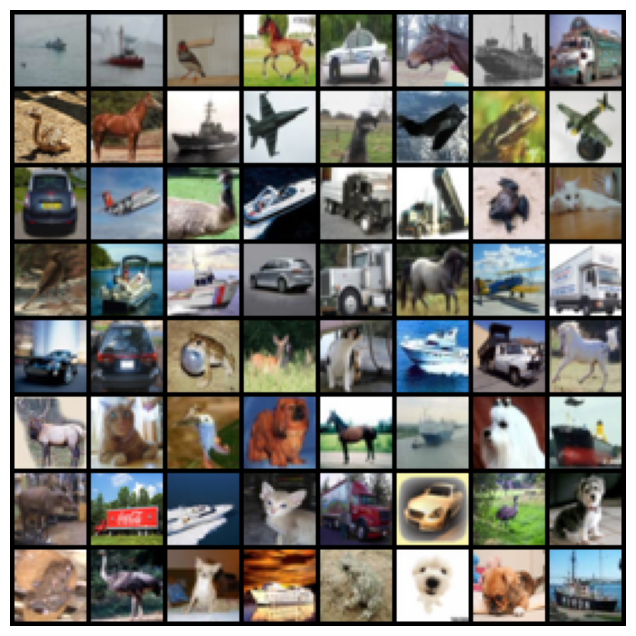

In [6]:
def show_grid(images):
    grid = make_grid(images[:64], nrow=8, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
    plt.axis("off")
    plt.show()


real_batch = next(iter(loader))[0]
show_grid(real_batch)

## 3. Архитектура Vanilla GAN

Генератор и дискриминатор на полносвязных слоях.

In [7]:
img_dim = CHANNELS * IMG_SIZE * IMG_SIZE


class VanillaGenerator(nn.Module):
    def __init__(self, latent_dim, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, img_dim),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z).view(-1, CHANNELS, IMG_SIZE, IMG_SIZE)


class VanillaDiscriminator(nn.Module):
    def __init__(self, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        return self.net(x.view(x.size(0), -1))

## 4. Архитектура DCGAN

Генератор на транспонированных свёртках и дискриминатор на свёртках с батч-нормализацией.

In [8]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, CHANNELS, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


class DCDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(CHANNELS, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

## 5. Функция обучения

Один цикл обучения для обеих моделей: шаг дискриминатора, затем шаг генератора. К меткам реальных изображений применено сглаживание для устойчивости.

In [9]:
def make_noise(n, is_conv):
    if is_conv:
        return torch.randn(n, LATENT_DIM, 1, 1, device=device)
    return torch.randn(n, LATENT_DIM, device=device)


def train_gan(G, D, epochs, is_conv):
    criterion = nn.BCEWithLogitsLoss()
    optG = torch.optim.Adam(G.parameters(), lr=LR, betas=(BETA1, 0.999))
    optD = torch.optim.Adam(D.parameters(), lr=LR, betas=(BETA1, 0.999))
    history = {"g_loss": [], "d_loss": [], "time": []}
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        g_sum, d_sum, steps = 0.0, 0.0, 0
        for real, _ in loader:
            real = real.to(device)
            b = real.size(0)
            real_labels = torch.full((b, 1), 0.9, device=device)
            fake_labels = torch.zeros(b, 1, device=device)

            noise = make_noise(b, is_conv)
            fake = G(noise)
            d_real = D(real)
            d_fake = D(fake.detach())
            d_loss = criterion(d_real, real_labels) + criterion(d_fake, fake_labels)
            optD.zero_grad()
            d_loss.backward()
            optD.step()

            output = D(fake)
            g_loss = criterion(output, torch.ones(b, 1, device=device))
            optG.zero_grad()
            g_loss.backward()
            optG.step()

            g_sum += g_loss.item()
            d_sum += d_loss.item()
            steps += 1
        history["g_loss"].append(g_sum / steps)
        history["d_loss"].append(d_sum / steps)
        history["time"].append(time.time() - t0)
        print(f"эпоха {epoch}/{epochs} d_loss={d_sum / steps:.3f} g_loss={g_sum / steps:.3f} ({history['time'][-1]:.0f} c)")
    return history

## 6. Обучение Vanilla GAN

In [10]:
torch.manual_seed(SEED)
vanilla_G = VanillaGenerator(LATENT_DIM, img_dim).to(device)
vanilla_D = VanillaDiscriminator(img_dim).to(device)
hist_vanilla = train_gan(vanilla_G, vanilla_D, EPOCHS, is_conv=False)

эпоха 1/40 d_loss=0.960 g_loss=1.403 (15 c)
эпоха 2/40 d_loss=0.947 g_loss=2.158 (14 c)
эпоха 3/40 d_loss=1.024 g_loss=1.919 (14 c)
эпоха 4/40 d_loss=1.111 g_loss=1.677 (15 c)
эпоха 5/40 d_loss=1.115 g_loss=1.554 (15 c)
эпоха 6/40 d_loss=1.146 g_loss=1.480 (14 c)
эпоха 7/40 d_loss=1.182 g_loss=1.404 (14 c)
эпоха 8/40 d_loss=1.200 g_loss=1.342 (14 c)
эпоха 9/40 d_loss=1.226 g_loss=1.270 (13 c)
эпоха 10/40 d_loss=1.215 g_loss=1.278 (14 c)
эпоха 11/40 d_loss=1.234 g_loss=1.241 (14 c)
эпоха 12/40 d_loss=1.240 g_loss=1.214 (14 c)
эпоха 13/40 d_loss=1.263 g_loss=1.172 (13 c)
эпоха 14/40 d_loss=1.265 g_loss=1.140 (14 c)
эпоха 15/40 d_loss=1.260 g_loss=1.136 (14 c)
эпоха 16/40 d_loss=1.276 g_loss=1.110 (14 c)
эпоха 17/40 d_loss=1.268 g_loss=1.101 (14 c)
эпоха 18/40 d_loss=1.275 g_loss=1.098 (14 c)
эпоха 19/40 d_loss=1.294 g_loss=1.071 (14 c)
эпоха 20/40 d_loss=1.303 g_loss=1.046 (14 c)
эпоха 21/40 d_loss=1.307 g_loss=1.024 (14 c)
эпоха 22/40 d_loss=1.302 g_loss=1.022 (14 c)
эпоха 23/40 d_loss=

## 7. Обучение DCGAN

In [11]:
torch.manual_seed(SEED)
dc_G = DCGenerator(LATENT_DIM).to(device)
dc_D = DCDiscriminator().to(device)
hist_dcgan = train_gan(dc_G, dc_D, EPOCHS, is_conv=True)

эпоха 1/40 d_loss=0.611 g_loss=4.152 (17 c)
эпоха 2/40 d_loss=0.688 g_loss=3.232 (17 c)
эпоха 3/40 d_loss=0.759 g_loss=2.875 (17 c)
эпоха 4/40 d_loss=0.728 g_loss=2.750 (17 c)
эпоха 5/40 d_loss=0.781 g_loss=2.671 (17 c)
эпоха 6/40 d_loss=0.774 g_loss=2.525 (17 c)
эпоха 7/40 d_loss=0.771 g_loss=2.536 (17 c)
эпоха 8/40 d_loss=0.760 g_loss=2.515 (17 c)
эпоха 9/40 d_loss=0.735 g_loss=2.509 (17 c)
эпоха 10/40 d_loss=0.785 g_loss=2.564 (17 c)
эпоха 11/40 d_loss=0.708 g_loss=2.559 (17 c)
эпоха 12/40 d_loss=0.732 g_loss=2.583 (17 c)
эпоха 13/40 d_loss=0.711 g_loss=2.536 (17 c)
эпоха 14/40 d_loss=0.720 g_loss=2.552 (17 c)
эпоха 15/40 d_loss=0.769 g_loss=2.519 (18 c)
эпоха 16/40 d_loss=0.683 g_loss=2.571 (17 c)
эпоха 17/40 d_loss=0.726 g_loss=2.562 (17 c)
эпоха 18/40 d_loss=0.678 g_loss=2.668 (18 c)
эпоха 19/40 d_loss=0.782 g_loss=2.587 (17 c)
эпоха 20/40 d_loss=0.647 g_loss=2.650 (17 c)
эпоха 21/40 d_loss=0.700 g_loss=2.765 (17 c)
эпоха 22/40 d_loss=0.696 g_loss=2.702 (17 c)
эпоха 23/40 d_loss=

## 8. Динамика потерь

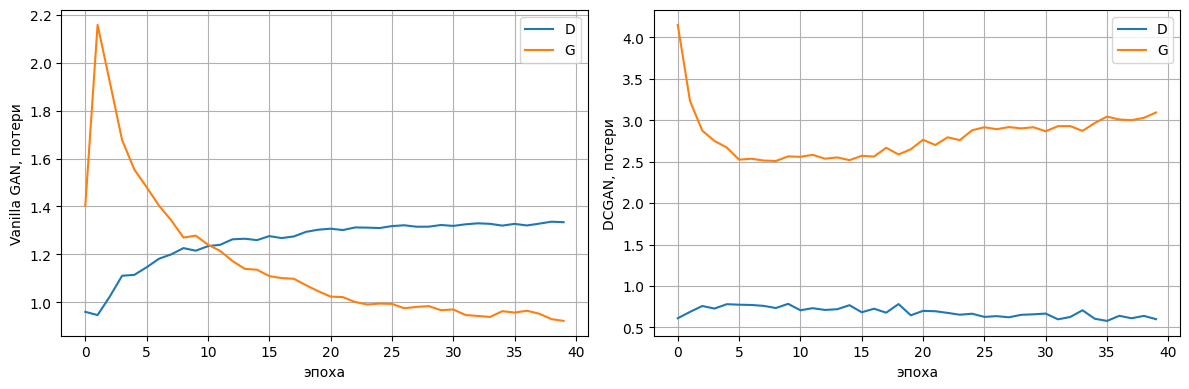

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist_vanilla["d_loss"], label="D")
ax[0].plot(hist_vanilla["g_loss"], label="G")
ax[0].set_ylabel("Vanilla GAN, потери")
ax[0].set_xlabel("эпоха")
ax[0].legend()
ax[0].grid(True)
ax[1].plot(hist_dcgan["d_loss"], label="D")
ax[1].plot(hist_dcgan["g_loss"], label="G")
ax[1].set_ylabel("DCGAN, потери")
ax[1].set_xlabel("эпоха")
ax[1].legend()
ax[1].grid(True)
plt.tight_layout()
plt.show()

## 9. Визуальная оценка сгенерированных изображений

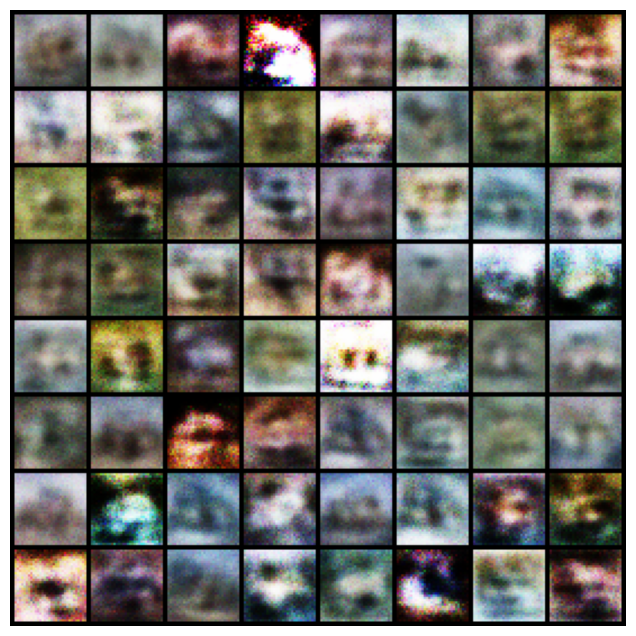

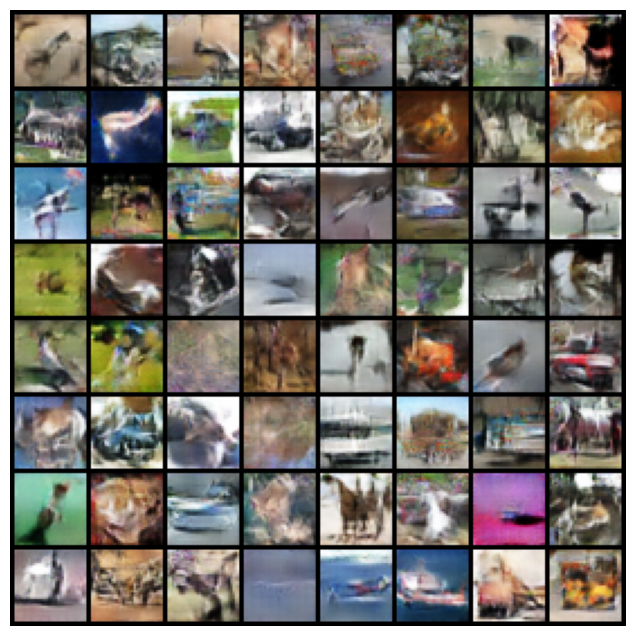

In [13]:
@torch.no_grad()
def sample(G, is_conv, n=64):
    G.eval()
    torch.manual_seed(SEED)
    z = make_noise(n, is_conv)
    return G(z).cpu()


show_grid(sample(vanilla_G, False))
show_grid(sample(dc_G, True))

## 10. Количественные метрики FID и Inception Score

FID сравнивает распределения настоящих и сгенерированных изображений (ниже лучше), Inception Score оценивает качество и разнообразие (выше лучше).

In [14]:
real_for_fid = []
collected = 0
for real, _ in loader:
    real_for_fid.append((real + 1) / 2)
    collected += real.size(0)
    if collected >= FID_SAMPLES:
        break
real_for_fid = torch.cat(real_for_fid)[:FID_SAMPLES]


@torch.no_grad()
def evaluate_gan(G, is_conv, name):
    G.eval()
    fid = FrechetInceptionDistance(normalize=True).to(device)
    inception = InceptionScore(normalize=True).to(device)
    for i in range(0, FID_SAMPLES, BATCH):
        fid.update(real_for_fid[i: i + BATCH].to(device), real=True)
    torch.manual_seed(SEED)
    made = 0
    while made < FID_SAMPLES:
        n = min(BATCH, FID_SAMPLES - made)
        fake = ((G(make_noise(n, is_conv)) + 1) / 2).clamp(0, 1)
        fid.update(fake, real=False)
        inception.update(fake)
        made += n
    fid_value = float(fid.compute())
    is_mean, _ = inception.compute()
    print(f"{name}: FID={fid_value:.2f}, IS={float(is_mean):.2f}")
    return fid_value, float(is_mean)


fid_vanilla, is_vanilla = evaluate_gan(vanilla_G, False, "Vanilla GAN")
fid_dcgan, is_dcgan = evaluate_gan(dc_G, True, "DCGAN")

Vanilla GAN: FID=278.13, IS=2.38
DCGAN: FID=58.01, IS=5.54


## 11. Интерполяция в латентном пространстве

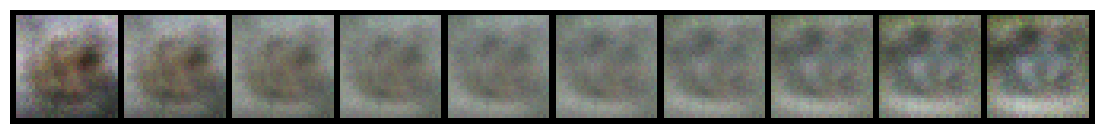

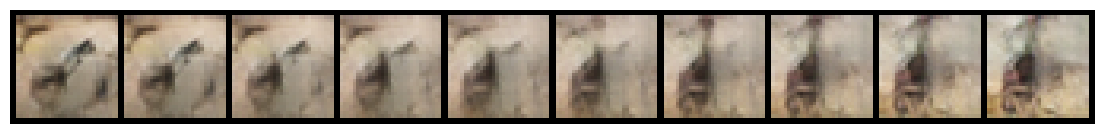

In [15]:
@torch.no_grad()
def interpolate(G, is_conv, name):
    G.eval()
    torch.manual_seed(SEED)
    z1 = make_noise(1, is_conv)
    z2 = make_noise(1, is_conv)
    shape = [-1] + [1] * (z1.dim() - 1)
    alphas = torch.linspace(0, 1, 10, device=device).view(*shape)
    z = (1 - alphas) * z1 + alphas * z2
    imgs = G(z).cpu()
    grid = make_grid(imgs, nrow=10, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(14, 2))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis("off")
    plt.show()


interpolate(vanilla_G, False, "Vanilla GAN")
interpolate(dc_G, True, "DCGAN")

## 12. Сравнение моделей

In [16]:
import pandas as pd


def count_params(*models):
    return round(sum(p.numel() for m in models for p in m.parameters()) / 1e6, 2)


summary = pd.DataFrame([
    {"модель": "Vanilla GAN", "FID (ниже лучше)": round(fid_vanilla, 2), "IS (выше лучше)": round(is_vanilla, 2),
     "параметры, млн": count_params(vanilla_G, vanilla_D),
     "сек/эпоху": round(sum(hist_vanilla["time"]) / len(hist_vanilla["time"]), 1)},
    {"модель": "DCGAN", "FID (ниже лучше)": round(fid_dcgan, 2), "IS (выше лучше)": round(is_dcgan, 2),
     "параметры, млн": count_params(dc_G, dc_D),
     "сек/эпоху": round(sum(hist_dcgan["time"]) / len(hist_dcgan["time"]), 1)},
])
print(summary.to_string(index=False))

     модель  FID (ниже лучше)  IS (выше лучше)  параметры, млн  сек/эпоху
Vanilla GAN            278.13             2.38            5.54       13.8
      DCGAN             58.01             5.54            1.73       16.9


## Выводы и ответы на контрольные вопросы

### Как работает генеративно-состязательная сеть

GAN состоит из двух сетей, которые обучаются вместе и соревнуются. Генератор получает
случайный шум и пытается превратить его в правдоподобное изображение, а дискриминатор
учится отличать настоящие изображения от сгенерированных. Генератор стремится обмануть
дискриминатор, а дискриминатор — не дать себя обмануть. В равновесии генератор выдаёт
изображения, которые дискриминатор уже не может уверенно отличить от настоящих.

### Чем DCGAN лучше базового GAN

Базовый GAN использует полносвязные слои и плохо улавливает пространственную структуру
изображений, поэтому его картинки получаются шумными и нестабильными при обучении.
DCGAN построен на свёрточных слоях, батч-нормализации и подходящих функциях активации,
что хорошо подходит для изображений. По метрикам это видно: у DCGAN ниже FID и выше
Inception Score, а сгенерированные картинки заметно качественнее.

### Метрики FID и Inception Score

Inception Score оценивает сгенерированные изображения по тому, насколько уверенно
классификатор Inception относит их к классам и насколько они разнообразны; чем выше, тем
лучше. FID (Fréchet Inception Distance) сравнивает распределения признаков настоящих и
сгенерированных изображений: чем ближе распределения, тем ниже FID, поэтому меньшее
значение лучше. Метрики посчитаны на 5000 изображений (рекомендуется не менее 10000),
поэтому абсолютные значения FID немного завышены и шумны — корректно сравнивать модели
между собой, а не с табличными ориентирами из литературы.

### Динамика обучения и латентное пространство

По графикам потерь видно характерное для GAN поведение: потери генератора и
дискриминатора колеблются, отражая их соревнование, и не стремятся к нулю. Интерполяция
в латентном пространстве показывает, что близкие векторы шума дают плавно меняющиеся
изображения — значит, сеть выучила осмысленное представление, а не запомнила отдельные
картинки.